In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_excel('Data_Train.csv')

In [3]:
df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882


In [4]:
df.tail(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
df.sample(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9096,IndiGo,21/05/2019,Banglore,Delhi,BLR → DEL,10:10,13:00,2h 50m,non-stop,No info,3943
385,SpiceJet,27/03/2019,Chennai,Kolkata,MAA → CCU,17:45,20:05,2h 20m,non-stop,No info,3384
881,Air India,15/05/2019,Kolkata,Banglore,CCU → BOM → COK → BLR,09:25,13:45 16 May,28h 20m,2 stops,No info,15532


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
df.shape

(10683, 11)

In [8]:
df.ndim

2

In [9]:
df.size

117513

In [10]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.shape

(10682, 11)

In [13]:
df.duplicated().sum()

220

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(10462, 11)

In [16]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [17]:
df['Total_Stops']=df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4})

In [18]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,0,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,0,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,0,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,0,No info,12648


In [19]:
df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [20]:
mask=df['Additional_Info']=='No Info'

In [21]:
df[mask]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
795,IndiGo,01/03/2019,Banglore,New Delhi,BLR → HYD → DEL,16:55,21:50,4h 55m,1,No Info,8153
2212,IndiGo,01/03/2019,Banglore,New Delhi,BLR → HYD → DEL,16:15,20:35,4h 20m,1,No Info,7917
9220,IndiGo,01/03/2019,Banglore,New Delhi,BLR → HYD → DEL,05:15,10:00,4h 45m,1,No Info,8064


In [22]:
df.drop(['Additional_Info'], inplace=True, axis=1)

In [23]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,13302
...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,0,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,0,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,0,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,0,12648


In [24]:
df.drop(['Route'],axis=1,inplace=True)

In [25]:
df

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302
...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,19:55,22:25,2h 30m,0,4107
10679,Air India,27/04/2019,Kolkata,Banglore,20:45,23:20,2h 35m,0,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,08:20,11:20,3h,0,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,11:30,14:10,2h 40m,0,12648


In [26]:
df['journey_day']=pd.to_datetime(df.Date_of_Journey,format='%d/%m/%Y').dt.day

In [27]:
df

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,journey_day
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897,24
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662,1
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882,9
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218,12
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302,1
...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,19:55,22:25,2h 30m,0,4107,9
10679,Air India,27/04/2019,Kolkata,Banglore,20:45,23:20,2h 35m,0,4145,27
10680,Jet Airways,27/04/2019,Banglore,Delhi,08:20,11:20,3h,0,7229,27
10681,Vistara,01/03/2019,Banglore,New Delhi,11:30,14:10,2h 40m,0,12648,1


In [28]:
df['journey_month']=pd.to_datetime(df.Date_of_Journey, format='%d/%m/%Y').dt.month

In [29]:
df

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,journey_day,journey_month
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662,1,5
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882,9,6
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218,12,5
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,19:55,22:25,2h 30m,0,4107,9,4
10679,Air India,27/04/2019,Kolkata,Banglore,20:45,23:20,2h 35m,0,4145,27,4
10680,Jet Airways,27/04/2019,Banglore,Delhi,08:20,11:20,3h,0,7229,27,4
10681,Vistara,01/03/2019,Banglore,New Delhi,11:30,14:10,2h 40m,0,12648,1,3


In [30]:
df.drop(['Date_of_Journey'],axis=1, inplace=True)

In [31]:
df

,Airline,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,journey_day,journey_month
0,IndiGo,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897,24,3
1,Air India,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662,1,5
2,Jet Airways,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882,9,6
3,IndiGo,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218,12,5
4,IndiGo,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302,1,3
...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,19:55,22:25,2h 30m,0,4107,9,4
10679,Air India,Kolkata,Banglore,20:45,23:20,2h 35m,0,4145,27,4
10680,Jet Airways,Banglore,Delhi,08:20,11:20,3h,0,7229,27,4
10681,Vistara,Banglore,New Delhi,11:30,14:10,2h 40m,0,12648,1,3


In [32]:
df['dep_hr']=pd.to_datetime(df.Dep_Time).dt.hour

In [33]:
df

,Airline,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,journey_day,journey_month,dep_hr
0,IndiGo,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897,24,3,22
1,Air India,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662,1,5,5
2,Jet Airways,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882,9,6,9
3,IndiGo,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218,12,5,18
4,IndiGo,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302,1,3,16
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,19:55,22:25,2h 30m,0,4107,9,4,19
10679,Air India,Kolkata,Banglore,20:45,23:20,2h 35m,0,4145,27,4,20
10680,Jet Airways,Banglore,Delhi,08:20,11:20,3h,0,7229,27,4,8
10681,Vistara,Banglore,New Delhi,11:30,14:10,2h 40m,0,12648,1,3,11


In [34]:
df['dep_min']=pd.to_datetime(df.Dep_Time).dt.minute

In [35]:
df

,Airline,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,journey_day,journey_month,dep_hr,dep_min
0,IndiGo,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897,24,3,22,20
1,Air India,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302,1,3,16,50
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,19:55,22:25,2h 30m,0,4107,9,4,19,55
10679,Air India,Kolkata,Banglore,20:45,23:20,2h 35m,0,4145,27,4,20,45
10680,Jet Airways,Banglore,Delhi,08:20,11:20,3h,0,7229,27,4,8,20
10681,Vistara,Banglore,New Delhi,11:30,14:10,2h 40m,0,12648,1,3,11,30


In [36]:
df.drop(['Dep_Time'], axis=1, inplace=True)

In [37]:
df

,Airline,Source,Destination,Arrival_Time,Duration,Total_Stops,Price,journey_day,journey_month,dep_hr,dep_min
0,IndiGo,Banglore,New Delhi,01:10 22 Mar,2h 50m,0,3897,24,3,22,20
1,Air India,Kolkata,Banglore,13:15,7h 25m,2,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,04:25 10 Jun,19h,2,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,23:30,5h 25m,1,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,21:35,4h 45m,1,13302,1,3,16,50
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,22:25,2h 30m,0,4107,9,4,19,55
10679,Air India,Kolkata,Banglore,23:20,2h 35m,0,4145,27,4,20,45
10680,Jet Airways,Banglore,Delhi,11:20,3h,0,7229,27,4,8,20
10681,Vistara,Banglore,New Delhi,14:10,2h 40m,0,12648,1,3,11,30


In [38]:
df[['Arr_time', 'date', 'month']]=df['Arrival_Time'].str.split(expand=True)

In [39]:
df.drop(['date','month','Arrival_Time'],axis=1,inplace=True)

In [40]:
df

,Airline,Source,Destination,Duration,Total_Stops,Price,journey_day,journey_month,dep_hr,dep_min,Arr_time
0,IndiGo,Banglore,New Delhi,2h 50m,0,3897,24,3,22,20,01:10
1,Air India,Kolkata,Banglore,7h 25m,2,7662,1,5,5,50,13:15
2,Jet Airways,Delhi,Cochin,19h,2,13882,9,6,9,25,04:25
3,IndiGo,Kolkata,Banglore,5h 25m,1,6218,12,5,18,5,23:30
4,IndiGo,Banglore,New Delhi,4h 45m,1,13302,1,3,16,50,21:35
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,2h 30m,0,4107,9,4,19,55,22:25
10679,Air India,Kolkata,Banglore,2h 35m,0,4145,27,4,20,45,23:20
10680,Jet Airways,Banglore,Delhi,3h,0,7229,27,4,8,20,11:20
10681,Vistara,Banglore,New Delhi,2h 40m,0,12648,1,3,11,30,14:10


In [41]:
df['arr_hr']=pd.to_datetime(df.Arr_time).dt.hour
df['arr_min']=pd.to_datetime(df.Arr_time).dt.minute

In [43]:
df.drop(['Arr_time'],axis=1,inplace=True)

In [44]:
df

,Airline,Source,Destination,Duration,Total_Stops,Price,journey_day,journey_month,dep_hr,dep_min,arr_hr,arr_min
0,IndiGo,Banglore,New Delhi,2h 50m,0,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,7h 25m,2,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,19h,2,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,5h 25m,1,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,4h 45m,1,13302,1,3,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,2h 30m,0,4107,9,4,19,55,22,25
10679,Air India,Kolkata,Banglore,2h 35m,0,4145,27,4,20,45,23,20
10680,Jet Airways,Banglore,Delhi,3h,0,7229,27,4,8,20,11,20
10681,Vistara,Banglore,New Delhi,2h 40m,0,12648,1,3,11,30,14,10


In [45]:
df.duplicated().sum()

2

In [48]:
df.drop_duplicates(inplace=True)

In [50]:
df.shape

(10460, 12)

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Airline', ylabel='count'>

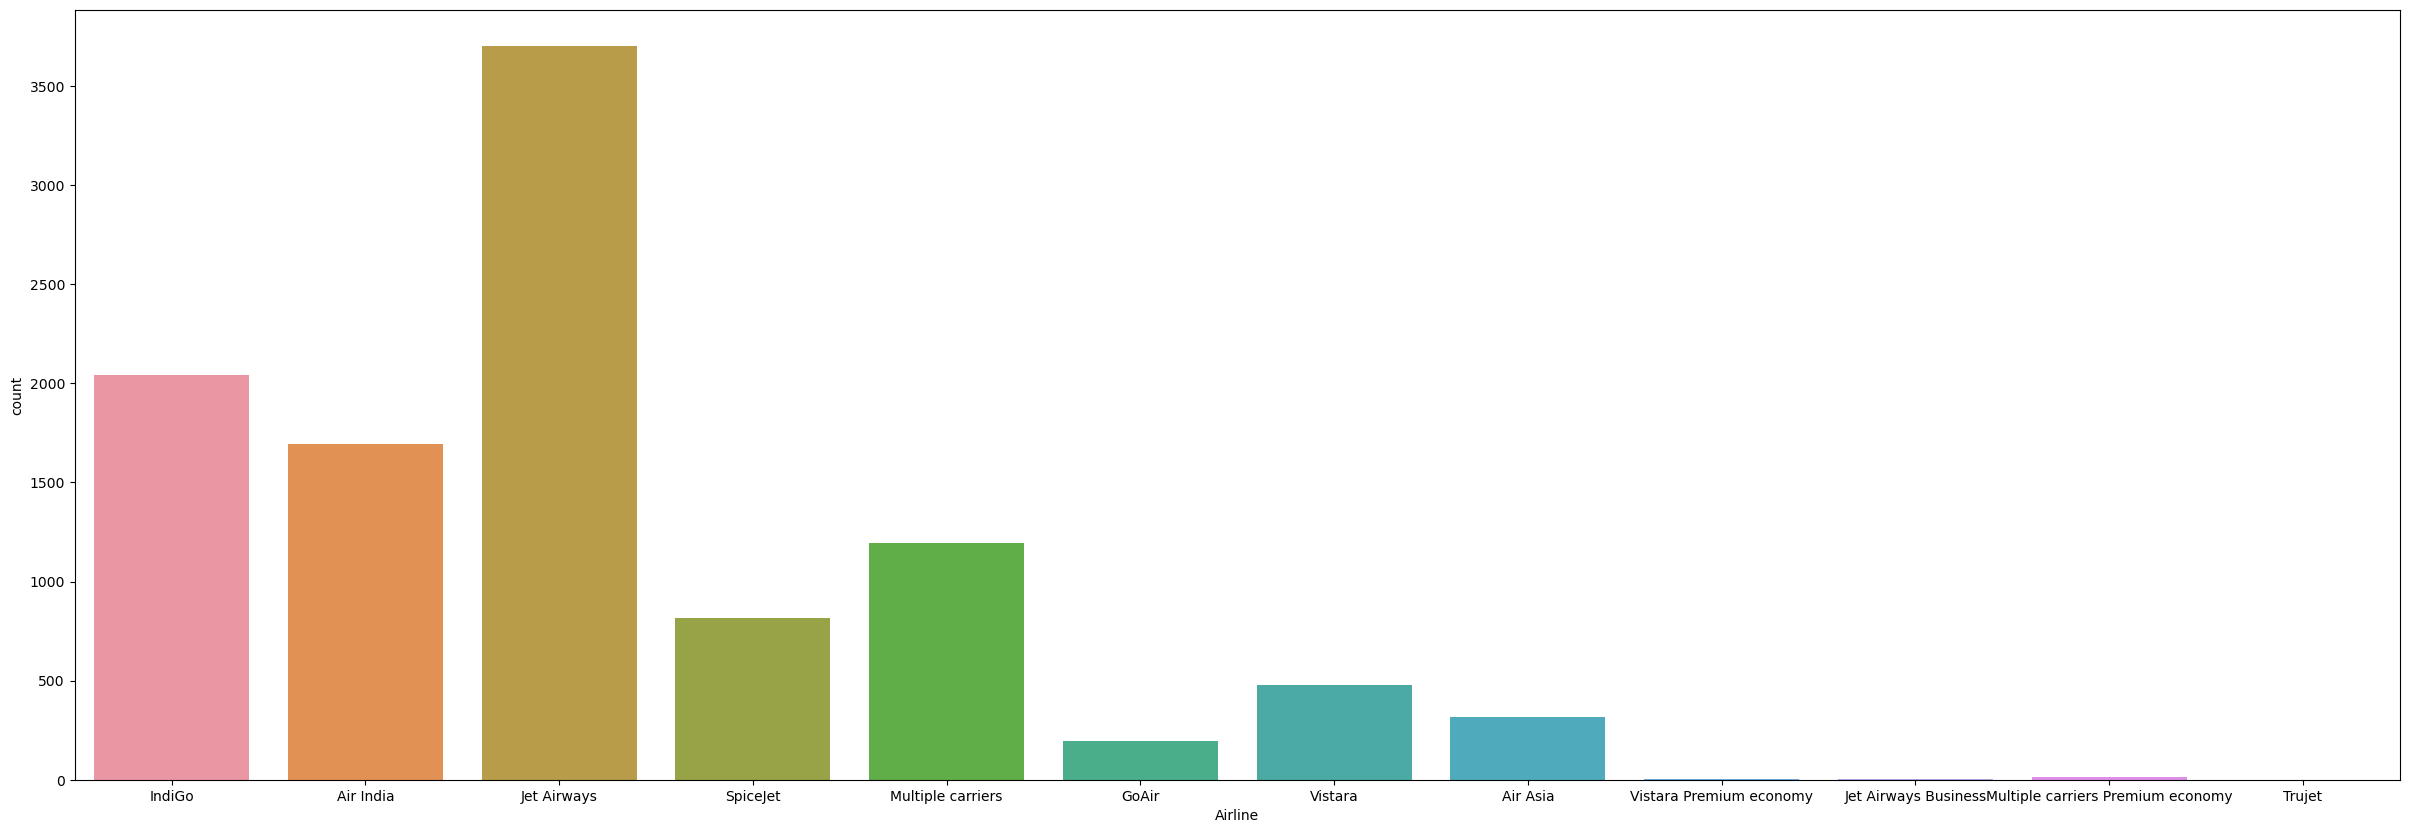

In [62]:
plt.figure(figsize=(30,10))
sns.countplot('Airline', data=df)

In [63]:
df['Airline'].value_counts()

Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               477
Air Asia                              318
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: Airline, dtype: int64